In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [47]:
# Загрузка исторических данных

name = "3BackTestData"
filename = f"data/{name}.csv"
data = pd.read_csv(filename, parse_dates=['timestamp'])
data.set_index('timestamp', inplace=True)

In [48]:
# Стратегия

# short_window = 200
# long_window = 50
#
# data['SMA200'] = data['close'].rolling(window=short_window).mean()
# data['SMA50'] = data['close'].rolling(window=long_window).mean()
#
# # Сигналы: 1 = покупка, -1 = продажа, 0 = держать
# data['signal'] = 0
# data.loc[data['SMA200'] > data['SMA50'], 'signal'] = 1
# data.loc[data['SMA200'] < data['SMA50'], 'signal'] = -1

In [49]:
# Бэктестинг

initial_cash = 1000 # стартовый капитал
cash = initial_cash # свободные деньги (зафиксированы)
investments = 0 # деньги в активах (могут меняться)
portfolio_values = [initial_cash]

positions = []  # список открытых позиций
trade_log = []

commission = 0.001  # 0.1% комиссия
#trade_fraction = 0.1  # 10% от портфеля на одну сделку
trade_amount = 100 # фикс сумма на сделку

for i in range(1, len(data)):
    price = data['open'].iloc[i]
    signal = data['signal'].iloc[i - 1]

    # --- Покупка ---
    if signal == 1 and cash >= trade_amount:
        #trade_amount = cash * trade_fraction
        position_size = trade_amount / price
        cash -= trade_amount + trade_amount * commission
        positions.append({'size': position_size, 'price': price})
        investments = sum([p['size'] * price for p in positions])
        portfolio_value = cash + investments
        trade_log.append({'date': data.index[i], 'type': 'buy', 'position_size': position_size, 'price': price,
            'investments': investments, 'cash': cash, 'portfolio': portfolio_value, 'PnL': 0})

    # --- Продажа (закрываем только одну позицию) ---
    elif signal == -1 and len(positions) > 0:
        pos = positions.pop(0)  # FIFO — закрываем первую открытую сделку
        PnL = pos['size'] * price - pos['size'] * pos['price']
        cash += pos['size'] * price
        cash -= pos['size'] * price * commission
        investments = sum([p['size'] * price for p in positions])
        portfolio_value = cash + investments
        trade_log.append({'date': data.index[i], 'type': 'sell', 'position_size': pos['size'], 'price': price,
            'investments': investments, 'cash': cash, 'portfolio': portfolio_value, 'PnL': PnL})

#     # Текущая стоимость портфеля = наличные + все открытые позиции по текущей цене
#     portfolio_value = cash + sum([p['size'] * price for p in positions])
#     portfolio_values.append(portfolio_value)
#
# data['portfolio'] = portfolio_values
# data['open_positions'] = [len(positions) for _ in range(len(data))]


In [50]:
data

,open,high,low,close,volume,signal
timestamp,,,,,,
2025-03-11 22:00:00,100.0,100.5,99.5,100.0,1000,1
2025-03-11 23:00:00,100.0,101.5,100.5,101.0,1000,1
2025-03-12 00:00:00,101.0,102.5,101.5,102.0,1000,0
2025-03-12 01:00:00,102.0,101.5,100.5,101.0,1000,0
2025-03-12 02:00:00,101.0,100.5,99.5,100.0,1000,-1
2025-03-12 03:00:00,100.0,101.5,100.5,101.0,1000,-1
2025-03-12 04:00:00,101.0,102.5,101.5,102.0,1000,1
2025-03-12 05:00:00,102.0,101.5,100.5,101.0,1000,-1
2025-03-12 06:00:00,102.0,100.5,99.5,100.0,1000,0


In [51]:
trade_log_df = pd.DataFrame(trade_log).set_index('date')
trade_log_df

,type,position_size,price,investments,cash,portfolio,PnL
date,,,,,,,
2025-03-11 23:00:00,buy,1.000000,100.0,100.000000,899.9,999.900000,0.0
2025-03-12 00:00:00,buy,0.990099,101.0,201.000000,799.8,1000.800000,0.0
2025-03-12 03:00:00,sell,1.000000,100.0,99.009901,899.7,998.709901,0.0
2025-03-12 04:00:00,sell,0.990099,101.0,0.000000,999.6,999.600000,0.0
2025-03-12 05:00:00,buy,0.980392,102.0,100.000000,899.5,999.500000,0.0
2025-03-12 06:00:00,sell,0.980392,102.0,0.000000,999.4,999.400000,0.0


In [52]:
# filename = f"logs/{name}_trade_log.csv"
# trade_log_df.to_csv(filename, index=False)
# print(f"\nДанные сохранены в файл: {filename}")

In [53]:
# Анализ результатов

# Подсчёт прибыльных и убыточных сделок
profits = []
for i in range(0, len(trade_log_df)-1, 2):
    buy = trade_log_df.iloc[i]['price']
    sell = trade_log_df.iloc[i + 1]['price']
    profits.append(sell - buy)
profits = np.array(profits)
num_trades = len(profits)
num_wins = np.sum(profits > 0)
win_rate = num_wins / num_trades * 100 if num_trades > 0 else 0

# Максимальная просадка
portfolio_array = np.array(portfolio_values)
running_max = np.maximum.accumulate(portfolio_array)
drawdown = (running_max - portfolio_array) / running_max
max_drawdown = np.max(drawdown) * 100

total_return = (portfolio_values[-1] - initial_cash) / initial_cash * 100

In [54]:
# --- 5. Вывод статистики ---
print(f"Общая доходность: {total_return:.2f}%")
print(f"Количество сделок: {num_trades}")
print(f"Процент прибыльных сделок: {win_rate:.2f}%")
print(f"Максимальная просадка: {max_drawdown:.2f}%")

Общая доходность: 0.00%
Количество сделок: 3
Процент прибыльных сделок: 66.67%
Максимальная просадка: 0.00%


In [55]:
# Анализ результатов
trade_df = pd.DataFrame(trade_log)

profits = []
closed_trades = []

open_trades = []

for _, row in trade_df.iterrows():
    if row['type'] == 'buy':
        open_trades.append(row['price'])

    elif row['type'] == 'sell' and len(open_trades) > 0:
        buy_price = open_trades.pop(0)
        sell_price = row['price']
        profit = sell_price - buy_price
        profits.append(profit)

        closed_trades.append({
            'buy_price': buy_price,
            'sell_price': sell_price,
            'profit': profit
        })

profits = np.array(profits)

# --- Метрики ---
num_trades = len(profits)
num_wins = np.sum(profits > 0)
num_losses = np.sum(profits <= 0)

win_rate = (num_wins / num_trades * 100) if num_trades > 0 else 0

avg_profit = profits.mean() if num_trades > 0 else 0
avg_win = profits[profits > 0].mean() if num_wins > 0 else 0
avg_loss = profits[profits <= 0].mean() if num_losses > 0 else 0

profit_factor = abs(profits[profits > 0].sum() / profits[profits <= 0].sum()) if num_losses > 0 else np.inf

# --- Максимальная просадка ---
portfolio_array = np.array(portfolio_values)
running_max = np.maximum.accumulate(portfolio_array)
drawdown = (running_max - portfolio_array) / running_max
max_drawdown = np.max(drawdown) * 100

# --- Доходность ---
total_return = (portfolio_values[-1] - initial_cash) / initial_cash * 100

# --- 5. Вывод ---
print(f"Общая доходность: {total_return:.2f}%")
print(f"Количество закрытых сделок: {num_trades}")
print(f"Win rate: {win_rate:.2f}%")
print(f"Средняя прибыль на сделку: {avg_profit:.5f}")
print(f"Средний выигрыш: {avg_win:.5f}")
print(f"Средний убыток: {avg_loss:.5f}")
print(f"Profit factor: {profit_factor:.2f}")
print(f"Максимальная просадка: {max_drawdown:.2f}%")


Общая доходность: 0.00%
Количество закрытых сделок: 3
Win rate: 0.00%
Средняя прибыль на сделку: 0.00000
Средний выигрыш: 0.00000
Средний убыток: 0.00000
Profit factor: nan
Максимальная просадка: 0.00%


C:\Users\AESoldatov\AppData\Local\Temp\ipykernel_5000\4156555114.py:38: RuntimeWarning: invalid value encountered in scalar divide
  profit_factor = abs(profits[profits > 0].sum() / profits[profits <= 0].sum()) if num_losses > 0 else np.inf


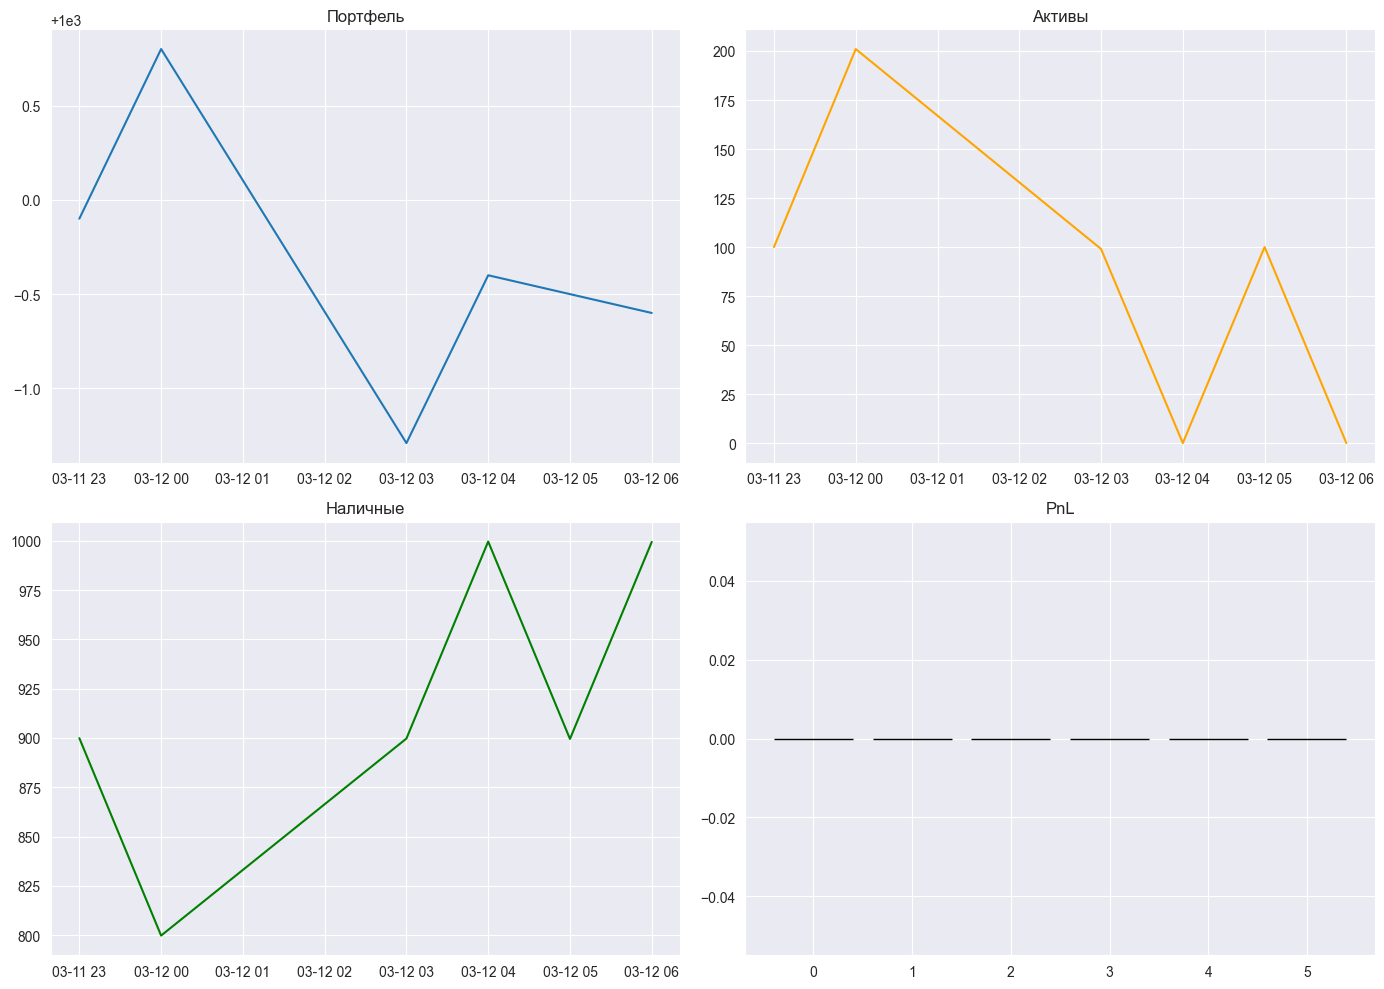

Графики успешно сохранены как 'plots/3BackTestData.png'


In [56]:
# Графики

fig, axs = plt.subplots(2, 2, figsize=(14, 10))  # 2×2 сетки

axs[0, 0].plot(trade_log_df.index, trade_log_df['portfolio'])
axs[0, 0].set_title('Портфель')
axs[0, 0].grid(True)

axs[0, 1].plot(trade_log_df.index, trade_log_df['investments'], color='orange')
axs[0, 1].set_title('Активы')
axs[0, 1].grid(True)

axs[1, 0].plot(trade_log_df.index, trade_log_df['cash'], color='green')
axs[1, 0].set_title('Наличные')
axs[1, 0].grid(True)

colors = ['green' if PnL >= 0 else 'red' for PnL in trade_log_df['PnL']]
axs[1, 1].bar(range(len(trade_log_df.index)), trade_log_df['PnL'], color=colors, edgecolor='black',)
axs[1, 1].set_title('PnL')
axs[1, 1].grid(True)

plt.tight_layout()
plt.savefig(f'plots/{name}.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print(f"Графики успешно сохранены как 'plots/{name}.png'")



In [57]:
trade_log_df.index

DatetimeIndex(['2025-03-11 23:00:00', '2025-03-12 00:00:00',
               '2025-03-12 03:00:00', '2025-03-12 04:00:00',
               '2025-03-12 05:00:00', '2025-03-12 06:00:00'],
              dtype='datetime64[us]', name='date', freq=None)